# Breast Cancer SVC: Forward Selection with Calibrated Probabilities

This example adapts the breast-cancer forward-selection workflow to `SVC(probability=True)`. MiSTIC uses calibrated positive-class probabilities for ROC scoring and contribution ranking, exposes them through `predict_proba`, and can explain them with integrated gradients.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, brier_score_loss,
                             classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

## Load and split the Wisconsin Diagnostic Breast Cancer data

In [2]:
data_path = Path("wdbc.data")
if not data_path.exists():
    data_path = Path("mistic/examples/wdbc.data")

properties = ["Radius", "Texture", "Perimeter", "Area", "Smoothness",
              "Compactness", "Concavity", "Concave Points", "Symmetry",
              "Fractal Dimension"]
columns = (["ID", "Diagnosis"] + [f"{name} mean" for name in properties]
           + [f"{name} SE" for name in properties]
           + [f"{name} worst" for name in properties])
data = pd.read_csv(data_path, header=None, names=columns)
X = data.drop(columns=["ID", "Diagnosis"])
y = data["Diagnosis"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0)
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()
data.shape, np.unique(y_train, return_counts=True)

((569, 32), (array(['B', 'M'], dtype=object), array([285, 170])))

## Configure probability-enabled SVC and forward selection

In [3]:
splits = cvSet(X=X_train, y=y_train)
splits.classification(num_sets=3, validation_size=0.20, random_seed=0)

svc = SVC(
    kernel="precomputed",
    class_weight="balanced",
    probability=True,
    random_state=0,
    tol=1e-12,
)
parameter_grid = [
    paramSet(model={"C": cost}, kernel={"gamma": gamma})
    for cost in (0.5, 2.0, 8.0)
    for gamma in (2**-7, 2**-4)
]

# The tuning score assigns 20% to 1-Brier probability calibration; the
# remaining 80% uses an equal ROC-AUC/F1 blend.
probability_scorer = score_svc(weight=0.5, calibration_weight=0.2)
ensemble = svmSet(
    svc, splits, score_method=probability_scorer.score,
    kernel=kernelWrapper(type="rbf"),
    separate_feature_sets=True,
    separate_parameters=True,
)

In [4]:
ensemble.greedy_forward_selection(
    parameter_grid=parameter_grid,
    addition_factor=0.20,
    max_features=12,
    feature_ranker=combined_rank(weight=0.90).compute,
    set_for_rank="sample",
    tune_models_each_step=True,
)

selected_features = X.columns[ensemble.unified_prediction_features_]
selected_features.tolist()

Number of Features: 1, Score: 0.957
Number of Features: 6, Score: 0.981
Number of Features: 10, Score: 0.986
Number of Features: 12, Score: 0.991
Number of Features: 30, Score: 0.996


['Radius worst',
 'Compactness worst',
 'Symmetry worst',
 'Compactness mean',
 'Smoothness worst',
 'Texture worst',
 'Fractal Dimension worst',
 'Texture mean',
 'Concavity worst',
 'Concave Points worst',
 'Concavity mean',
 'Texture SE']

## Selection curve and blind-test probability estimates

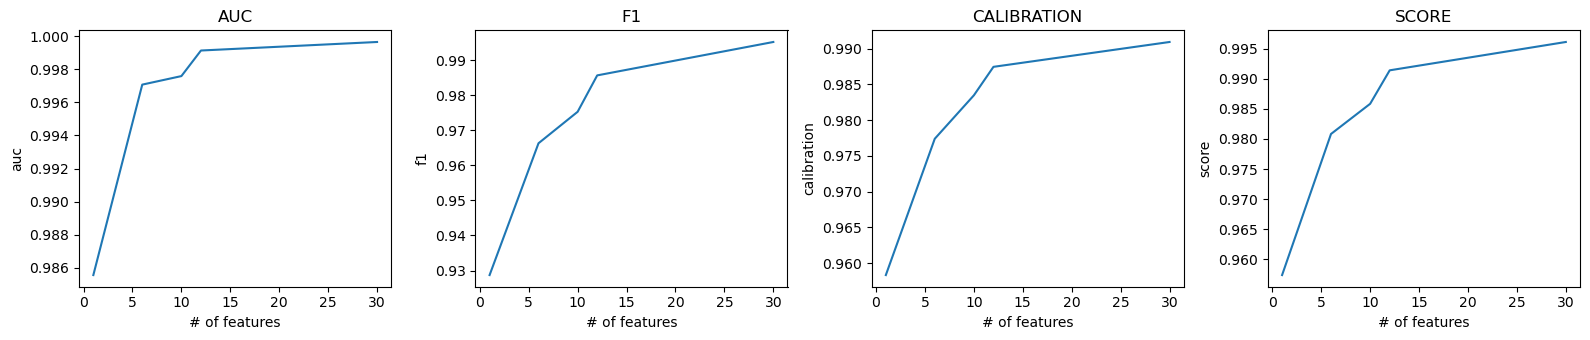

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, metric in zip(axes, ("auc", "f1", "calibration", "score")):
    plt.sca(ax)
    ensemble.plot_performance(metric=metric)
    ax.set_title(metric.upper())
fig.tight_layout()

Positive class: M
Blind-test ROC AUC: 0.996
Blind-test Brier loss: 0.025
              precision    recall  f1-score   support

           B       0.97      0.96      0.97        72
           M       0.93      0.95      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



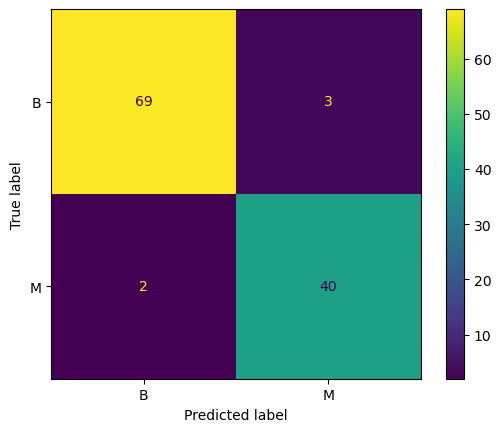

In [6]:
probability = ensemble.predict_proba(X_test)
positive_class = ensemble.unified_model_.classes_[1]
positive_probability = probability[:, 1]
prediction = ensemble.predict(X_test)

print(f"Positive class: {positive_class}")
print(f"Blind-test ROC AUC: {roc_auc_score(y_test, positive_probability):.3f}")
print(f"Blind-test Brier loss: {brier_score_loss(y_test, positive_probability, pos_label=positive_class):.3f}")
print(classification_report(y_test, prediction))
ConfusionMatrixDisplay.from_predictions(y_test, prediction)

In [7]:
# Row-level blind predictions from the final unified model. Probability
# columns follow unified_model_.classes_, which is [B, M] for this data.
member_set_probability = ensemble.predict_proba(
    X_test, prediction_mode="set")
blind_predictions = pd.DataFrame({
    "sample_id": data.loc[X_test_raw.index, "ID"].to_numpy(),
    "observed": y_test,
    "predicted": prediction,
    f"P({ensemble.unified_model_.classes_[0]})": probability[:, 0],
    f"P({ensemble.unified_model_.classes_[1]})": probability[:, 1],
    "member_set_positive_probability": member_set_probability[:, 1],
})
blind_predictions["correct"] = (
    blind_predictions["observed"] == blind_predictions["predicted"])
blind_predictions.to_csv("BreastCancer_forward_probability_blind_predictions.csv",
                         index=False)
blind_predictions

,sample_id,observed,predicted,P(B),P(M),member_set_positive_probability,correct
0,911673,B,B,9.982720e-01,0.001728,0.001692,True
1,925277,B,B,9.180202e-01,0.081980,0.031068,True
2,919812,B,B,7.311427e-01,0.268857,0.346974,True
3,894855,B,B,9.900506e-01,0.009949,0.016840,True
4,911391,B,B,9.996084e-01,0.000392,0.001743,True
...,...,...,...,...,...,...,...
109,9010877,B,B,9.955503e-01,0.004450,0.003390,True
110,917062,B,B,9.446441e-01,0.055356,0.223097,True
111,901011,B,B,9.999346e-01,0.000065,0.000302,True
112,851509,M,M,6.414150e-12,1.000000,1.000000,True


## Integrated gradients of positive-class probability

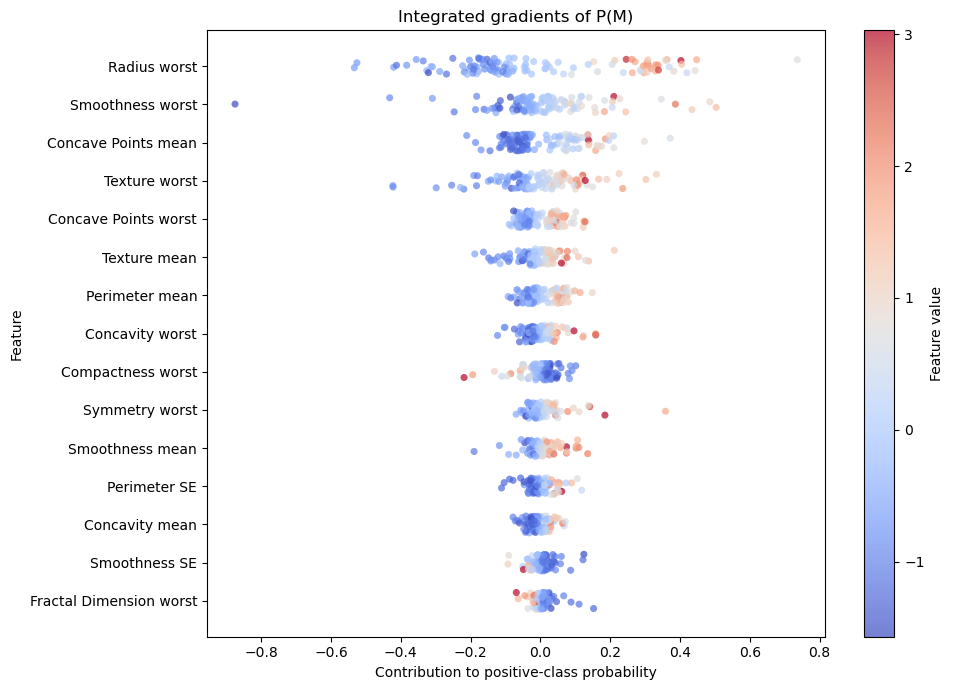

In [8]:
# Probability IG currently explains the mean member-set probability.
# A zero vector is a natural reference because the inputs are standardized.
reference = np.zeros(X_test.shape[1])
ig_probability = ensemble.explain_integrated_gradients(
    X_test,
    feature_names=X.columns,
    target=y_test,
    reference_point=reference,
    num_steps=100,
    output="probability",
)

fig, ax = plt.subplots(figsize=(10, 7))
ig_probability.summary_plot(
    ax=ax, max_features=15, cmap="coolwarm", random_state=0,
    scatter_kwargs={"s": 26, "alpha": 0.7, "edgecolors": "none"},
)
ax.set_title(f"Integrated gradients of P({positive_class})")
ax.set_xlabel("Contribution to positive-class probability")
plt.tight_layout()

In [9]:
# Completeness check: attribution sums approximate the change in the
# mean member-set probability relative to the reference.
reference_rows = np.broadcast_to(reference, X_test.shape)
expected_change = (
    ensemble.predict_proba(X_test, prediction_mode="set")[:, 1]
    - ensemble.predict_proba(reference_rows, prediction_mode="set")[:, 1]
)
attributed_change = ig_probability.values.sum(axis=1)
pd.DataFrame({
    "expected_probability_change": expected_change,
    "attributed_change": attributed_change,
    "residual": expected_change - attributed_change,
}).describe()

,expected_probability_change,attributed_change,residual
count,114.000000,114.000000,114.000000
mean,0.010716,0.010910,-0.000194
std,0.449787,0.449685,0.000827
min,-0.388591,-0.388654,-0.001661
25%,-0.385330,-0.385226,-0.000624
50%,-0.321585,-0.320623,-0.000066
75%,0.597839,0.598572,0.000161
max,0.611107,0.610070,0.001393
